In [1]:
import pandas as pd
from scipy.io import wavfile
import seaborn as sns
import matplotlib.pyplot as plt
import parselmouth
import numpy as np
import os

# pip install praat-parselmouth

In [2]:
df = pd.read_csv('audio.csv')
df.set_index('File_Name', inplace=True)

In [3]:
df.head()

,Actor,Gender,Emotion,Intensity,Statement,Repetition
File_Name,,,,,,
03-01-01-01-01-01-01.wav,1,M,neutral,normal,1,1
03-01-01-01-01-02-01.wav,1,M,neutral,normal,1,2
03-01-01-01-02-01-01.wav,1,M,neutral,normal,2,1
03-01-01-01-02-02-01.wav,1,M,neutral,normal,2,2
03-01-02-01-01-01-01.wav,1,M,calm,normal,1,1


In [4]:
for f in df.index:
    rate, signal = wavfile.read('data/'+f)
    df.at[f, 'length'] = signal.shape[0]/rate

C:\Users\barry\AppData\Local\Temp\ipykernel_25640\1458821718.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate, signal = wavfile.read('data/'+f)
C:\Users\barry\AppData\Local\Temp\ipykernel_25640\1458821718.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate, signal = wavfile.read('data/'+f)


In [5]:
print(df['Emotion'].value_counts())

Emotion
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64


In [6]:
print(df['Emotion'].unique())

['neutral' 'calm' 'happy' 'sad' 'angry' 'fearful' 'disgust' 'surprised']


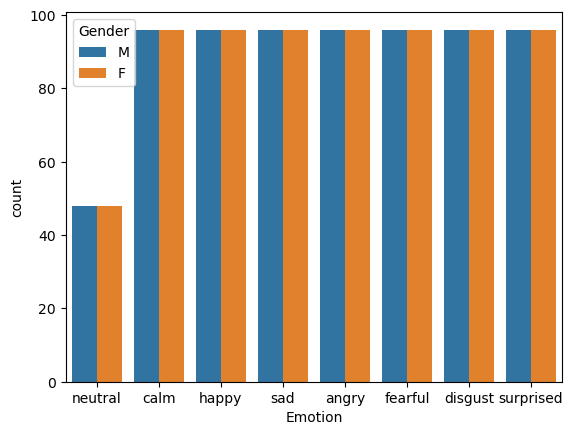

In [7]:
sns.countplot(x='Emotion', hue='Gender', data=df)

plt.show()


In [17]:
female_rows = df[df['Gender'] == 'F']

In [19]:
female_rows['Emotion'].value_counts()

Emotion
calm         96
happy        96
sad          96
angry        96
fearful      96
disgust      96
surprised    96
neutral      48
Name: count, dtype: int64

In [20]:
male_rows = df[df['Gender'] == 'M']
male_rows['Emotion'].value_counts()

Emotion
calm         96
happy        96
sad          96
angry        96
fearful      96
disgust      96
surprised    96
neutral      48
Name: count, dtype: int64

In [21]:
print(df.groupby("Emotion")['length'].mean())

Emotion
angry        3.871404
calm         3.795806
disgust      3.941785
fearful      3.574231
happy        3.638183
neutral      3.503153
sad          3.694490
surprised    3.487512
Name: length, dtype: float64


In [22]:
summary_stats = df['length'].describe()
print(summary_stats)

count    1440.000000
mean        3.700665
std         0.336676
min         2.936271
25%         3.470146
50%         3.670333
75%         3.870542
max         5.271937
Name: length, dtype: float64


In [43]:
summary_stats = df['Mean Pitch'].describe()
print(summary_stats)

count    1440.000000
mean       75.586350
std        31.487922
min        10.280634
25%        50.024654
50%        73.432354
75%        92.467235
max       214.392471
Name: Mean Pitch, dtype: float64


In [44]:
summary_stats = df['Mean Intensity'].describe()
print(summary_stats)

count    1440.000000
mean       16.916750
std        22.877321
min       -71.034977
25%        10.222175
50%        24.421577
75%        30.998400
max        55.166156
Name: Mean Intensity, dtype: float64


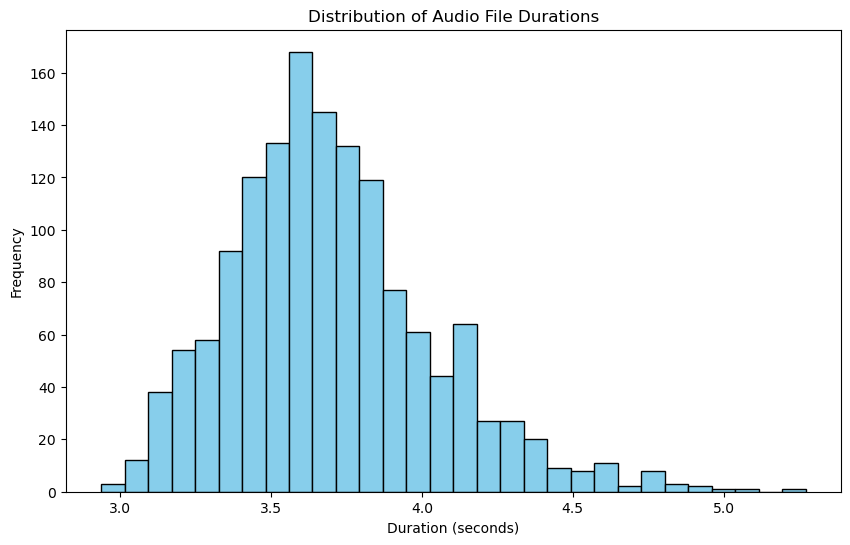

In [23]:
plt.figure(figsize=(10, 6))
plt.hist(df['length'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Audio File Durations')
plt.show()

In [29]:
length_df = pd.DataFrame(index=audio_files)
length_df = df['length']
print(length_df.head())

File_Name
03-01-01-01-01-01-01.wav    3.303292
03-01-01-01-01-02-01.wav    3.336667
03-01-01-01-02-01-01.wav    3.269917
03-01-01-01-02-02-01.wav    3.169833
03-01-02-01-01-01-01.wav    3.536854
Name: length, dtype: float64


In [30]:
length_df.to_csv('length.csv', index=False)

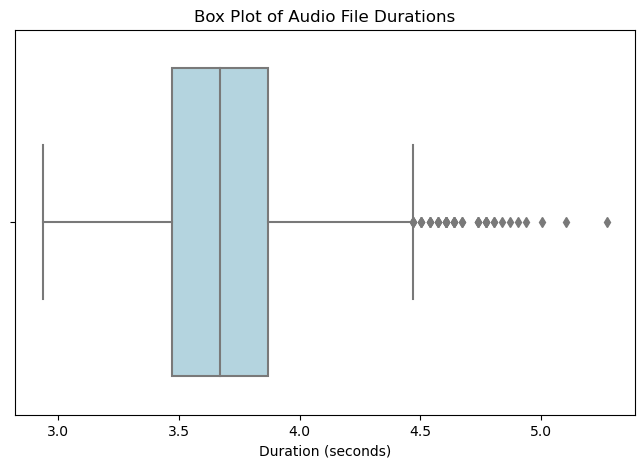

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['length'], color='lightblue')
plt.xlabel('Duration (seconds)')
plt.title('Box Plot of Audio File Durations')
plt.show()

<Axes: xlabel='Emotion', ylabel='Mean Intensity'>

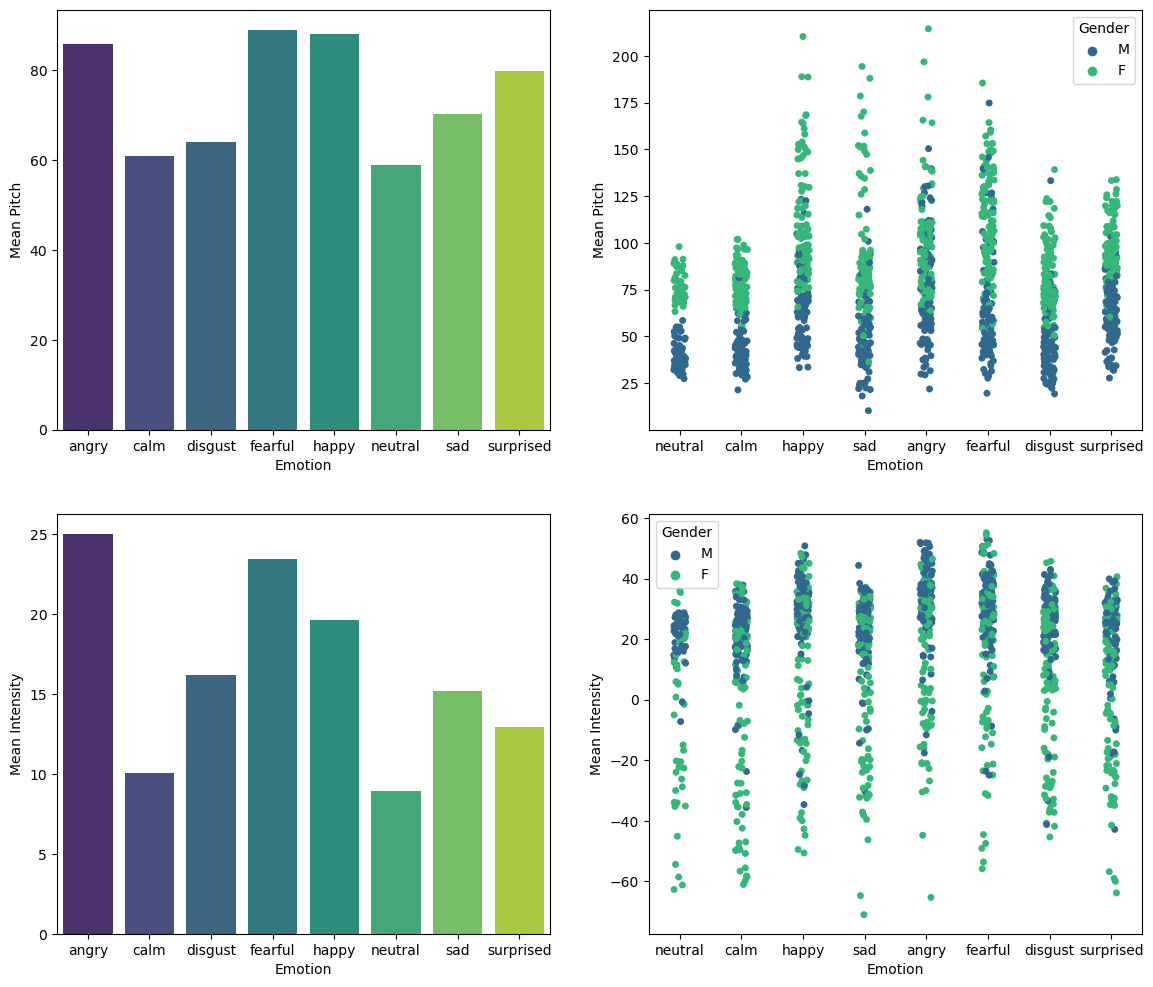

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [37]:
# Calculate mean or median for Pitch and Intensity
pitch_means = df.groupby('Emotion')['Mean Pitch'].mean().reset_index()
intensity_means = df.groupby('Emotion')['Mean Intensity'].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot for Pitch
plt.figure(figsize=(10, 6))
sns.barplot(x='Emotion', y='Mean Pitch', data=pitch_means, palette='viridis', ax=axes[0, 0])
sns.stripplot(data=df, x="Emotion", y="Mean Pitch", hue='Gender', palette='viridis', jitter=True, ax=axes[0, 1])
# plt.title('Pitch by Emotion')
# plt.xlabel('Emotion')
# plt.ylabel('Pitch')
# plt.show()

# Plot for Intensity
plt.figure(figsize=(10, 6))
sns.barplot(x='Emotion', y='Mean Intensity', data=intensity_means, palette='viridis', ax=axes[1, 0])
sns.stripplot(data=df, x="Emotion", y="Mean Intensity", hue='Gender', palette='viridis', jitter=True, ax=axes[1, 1])
# plt.title('Intensity by Emotion')
# plt.xlabel('Emotion')
# plt.ylabel('Intensity')
# plt.show()



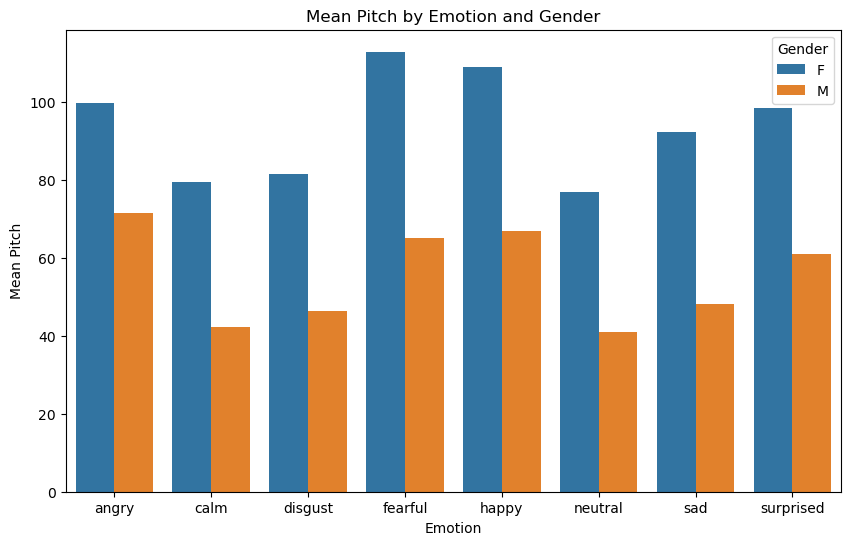

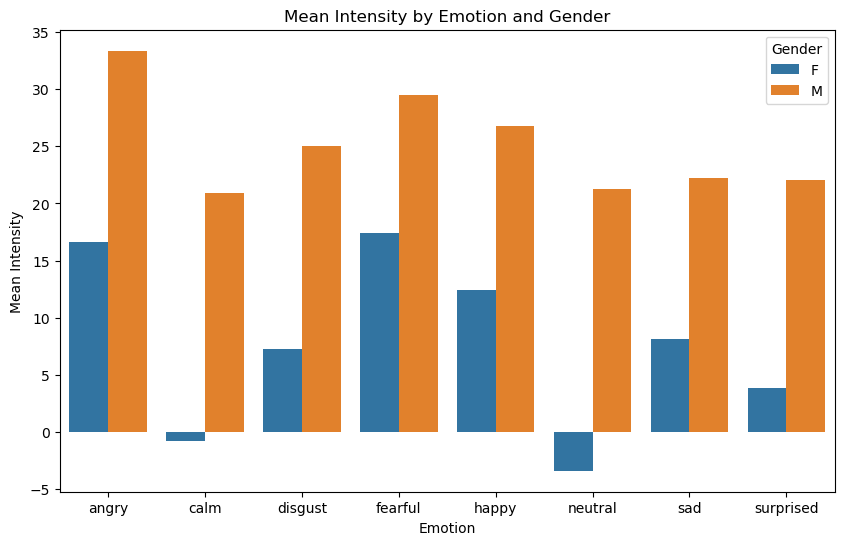

In [15]:
# Calculate mean for both Pitch and Intensity, grouped by Emotion and Gender
pitch_means = df.groupby(['Emotion', 'Gender'])['Mean Pitch'].mean().reset_index()
intensity_means = df.groupby(['Emotion', 'Gender'])['Mean Intensity'].mean().reset_index()

# Plot Mean Pitch
plt.figure(figsize=(10, 6))
sns.barplot(x='Emotion', y='Mean Pitch', hue='Gender', data=pitch_means)
plt.title('Mean Pitch by Emotion and Gender')
plt.ylabel('Mean Pitch')
plt.show()

# Plot Mean Intensity
plt.figure(figsize=(10, 6))
sns.barplot(x='Emotion', y='Mean Intensity', hue='Gender', data=intensity_means)
plt.title('Mean Intensity by Emotion and Gender')
plt.ylabel('Mean Intensity')
plt.show()

In [36]:
# Sort means in descending order
sorted_pitch_means = pitch_means.sort_values(by='Mean Pitch', ascending=False)
sorted_intensity_means = intensity_means.sort_values(by='Mean Intensity', ascending=False)

print("Average Pitch by Emotion:")
print(sorted_pitch_means)

print("\nAverage Intensity by Emotion:")
print(sorted_intensity_means)

Average Pitch by Emotion:
     Emotion  Mean Pitch
3    fearful   88.948250
4      happy   87.920750
0      angry   85.705901
7  surprised   79.713561
6        sad   70.245641
2    disgust   63.947939
1       calm   60.963129
5    neutral   58.904898

Average Intensity by Emotion:
     Emotion  Mean Intensity
0      angry       25.018208
3    fearful       23.456459
4      happy       19.600386
2    disgust       16.154021
6        sad       15.191765
7  surprised       12.951000
1       calm       10.037127
5    neutral        8.933323


In [40]:
from scipy.stats import pearsonr, spearmanr, kendalltau

# Pearson correlation
pearson_corr, _ = pearsonr(df['Mean Pitch'], df['Mean Intensity'])
print("Pearson correlation:", pearson_corr)

# Spearman correlation
spearman_corr, _ = spearmanr(df['Mean Pitch'], df['Mean Intensity'])
print("Spearman correlation:", spearman_corr)

# Kendall correlation
kendall_corr, _ = kendalltau(df['Mean Pitch'], df['Mean Intensity'])
print("Kendall correlation:", kendall_corr)

Pearson correlation: 0.008832705260363937
Spearman correlation: 0.0783363391345521
Kendall correlation: 0.05888643626596042


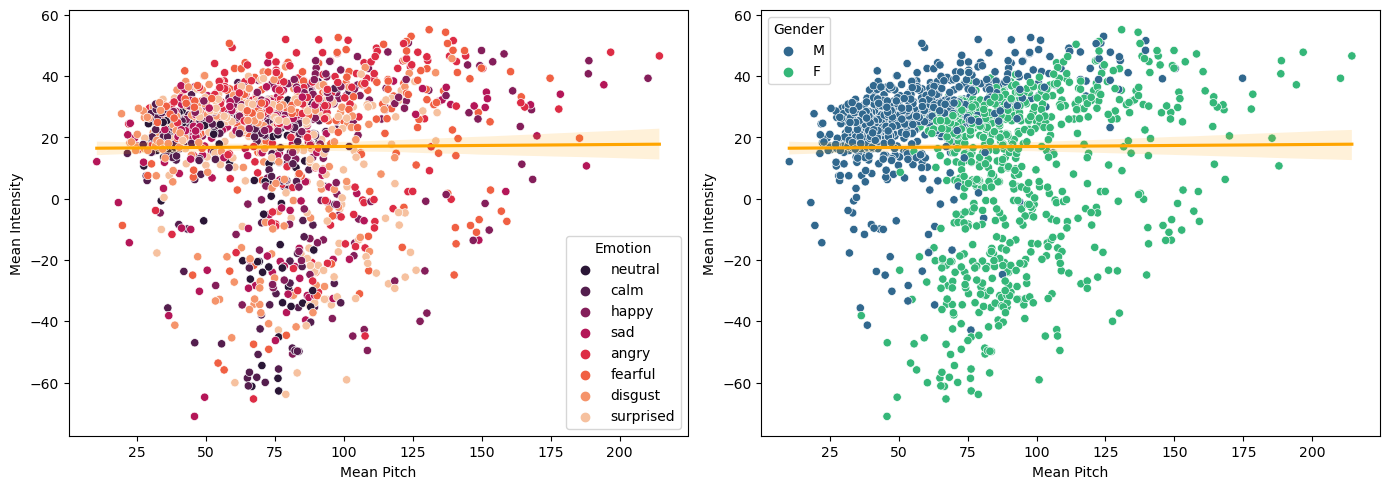

In [78]:
# Scatter plot with regression line

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='Mean Pitch', y='Mean Intensity', hue='Emotion', data=df, palette='rocket', ax=axes[0])
sns.scatterplot(x='Mean Pitch', y='Mean Intensity', hue='Gender', data=df, palette='viridis', ax=axes[1])
sns.regplot(x='Mean Pitch', y='Mean Intensity', data=df, scatter=False, color='orange', ax=axes[0])
sns.regplot(x='Mean Pitch', y='Mean Intensity', data=df, scatter=False, color='orange', ax=axes[1])
# plt.title('Scatter Plot of Pitch vs. Intensity')
# plt.xlabel('Mean Pitch')
# plt.ylabel('Mean Intensity')
# plt.grid(True)
plt.tight_layout()
plt.show()

# Mean Pitch

In [11]:
# Directory containing your audio files
audio_dir = "data/"

# List to store pitch data for each file
pitch_data = []

# List of audio files
audio_files = [f for f in os.listdir(audio_dir) if f.endswith(".wav")]

# Loop over each audio file
for file in audio_files:
    # Load the sound file
    snd = parselmouth.Sound(os.path.join(audio_dir, file))
    
    # Extract pitch
    pitch = snd.to_pitch()
    pitch_values = pitch.selected_array['frequency']
    
    # Use a summary statistic (e.g., mean, median) if pitch length differs across files
    pitch_mean = np.mean(pitch_values)
    
    df.at[file, 'Mean Pitch'] = pitch_mean
    # Append the pitch mean to pitch_data list
    #pitch_data.append(pitch_mean)

# Create a DataFrame with file names as index and pitch means as column
#df = pd.DataFrame(pitch_data, index=audio_files, columns=["Mean Pitch"])

In [12]:
df.head()

,Actor,Gender,Emotion,Intensity,Statement,Repetition,length,Mean Pitch
File_Name,,,,,,,,
03-01-01-01-01-01-01.wav,1,M,neutral,normal,1,1,3.303292,34.546637
03-01-01-01-01-02-01.wav,1,M,neutral,normal,1,2,3.336667,37.660537
03-01-01-01-02-01-01.wav,1,M,neutral,normal,2,1,3.269917,36.515771
03-01-01-01-02-02-01.wav,1,M,neutral,normal,2,2,3.169833,34.807093
03-01-02-01-01-01-01.wav,1,M,calm,normal,1,1,3.536854,39.075821


# Mean Intensity

In [13]:
# Directory containing your audio files
audio_dir = "data/"

# List to store intensity data for each file
intensity_data = []

# List of audio files
audio_files = [f for f in os.listdir(audio_dir) if f.endswith(".wav")]

# Loop over each audio file
for file in audio_files:
    # Load the sound file
    snd = parselmouth.Sound(os.path.join(audio_dir, file))
    
    # Extract intensity
    intensity = snd.to_intensity()
    intensity_values = intensity.values.T.flatten()  # Flatten to a 1D array
    
    # Use a summary statistic (e.g., mean) if intensity length differs across files
    intensity_mean = np.mean(intensity_values)
    
    df.at[file, 'Mean Intensity'] = intensity_mean
    
    # Append the intensity mean to intensity_data list
    #intensity_data.append(intensity_mean)

# Create a DataFrame with file names as index and intensity means as a column
#df = pd.DataFrame(intensity_data, index=audio_files, columns=["Mean Intensity"])

# Display the DataFrame
#print(df)


In [14]:
df.head()

,Actor,Gender,Emotion,Intensity,Statement,Repetition,length,Mean Pitch,Mean Intensity
File_Name,,,,,,,,,
03-01-01-01-01-01-01.wav,1,M,neutral,normal,1,1,3.303292,34.546637,13.611322
03-01-01-01-01-02-01.wav,1,M,neutral,normal,1,2,3.336667,37.660537,15.508136
03-01-01-01-02-01-01.wav,1,M,neutral,normal,2,1,3.269917,36.515771,14.725629
03-01-01-01-02-02-01.wav,1,M,neutral,normal,2,2,3.169833,34.807093,16.049077
03-01-02-01-01-01-01.wav,1,M,calm,normal,1,1,3.536854,39.075821,12.647445


# Extra

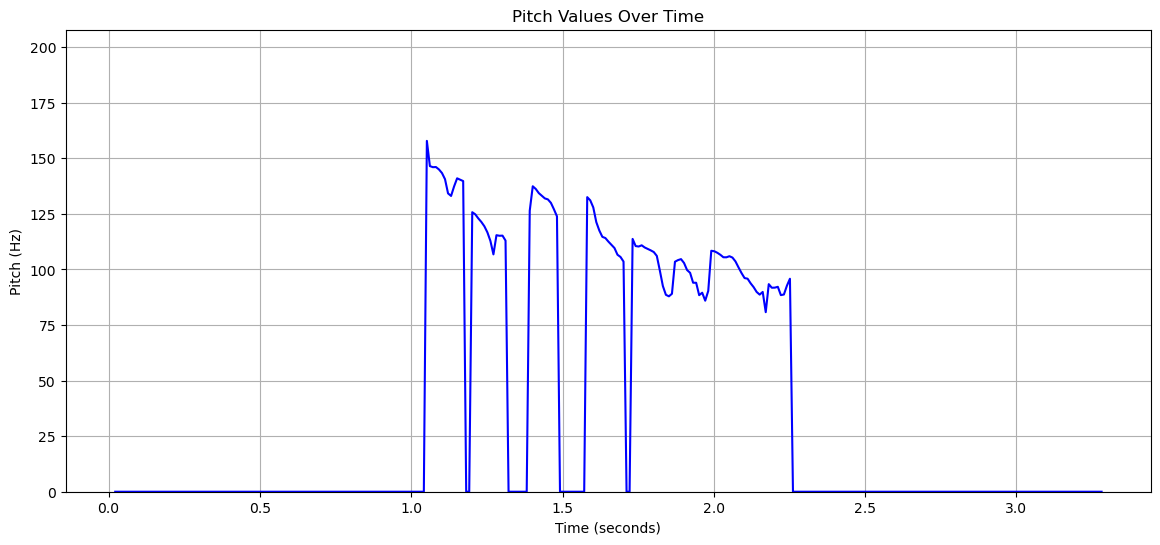

In [27]:
time_values = pitch.xs()  # Time in seconds

# Filter out NaN values for better plotting
valid_indices = ~np.isnan(pitch_values)
time_values = time_values[valid_indices]
pitch_values = pitch_values[valid_indices]

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(time_values, pitch_values, color='blue')
plt.title('Pitch Values Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Pitch (Hz)')
plt.ylim(0, np.max(pitch_values) + 50)  # Adjusting Y-axis limits
plt.grid()
plt.show()